# Exploratory Data Analysis (EDA) - Bank Customer Churn

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

df = pd.read_csv('../data/Bank Customer Churn Prediction.csv')

df.columns = df.columns.str.lower()
print(f"Loaded {df.shape[0]} rows for EDA.")

Loaded 10000 rows for EDA.


### Analyzing Churn rates overall & by segments

In [ ]:
overall_churn = df['churn'].mean() * 100
print(f"Overall Bank Churn Rate: {overall_churn:.2f}%\n")

df['age_group'] = pd.cut(df['age'], bins=[0, 30, 45, 60, 100], labels=['<30', '30-45', '45-60', '60+'])
age_churn = df.groupby('age_group', observed=False)['churn'].mean() * 100
print("Churn Rate by Age Group:")
print(age_churn.apply(lambda x: f"{x:.2f}%"), "\n")

df['salary_group'] = pd.qcut(df['estimated_salary'], q=4, labels=['Low', 'Medium-Low', 'Medium-High', 'High'])
salary_churn = df.groupby('salary_group', observed=False)['churn'].mean() * 100
print("Churn Rate by Salary Tier:")
print(salary_churn.apply(lambda x: f"{x:.2f}%"), "\n")

tenure_churn = df.groupby('tenure')['churn'].mean() * 100
print("Churn Rate by Tenure (Years):")
print(tenure_churn.apply(lambda x: f"{x:.2f}%"))


Overall Bank Churn Rate: 20.37%

Overall Bank Churn Rate: 20.37%

Churn Rate by Age Group:
age_group
<30       7.52%
30-45    15.74%
45-60    51.12%
60+      24.78%
Name: churn, dtype: object 

Churn Rate by Salary Tier:
salary_group
Low            20.00%
Medium-Low     19.80%
Medium-High    20.12%
High           21.56%
Name: churn, dtype: object 

Churn Rate by Tenure (Years):
tenure
0     23.00%
1     22.42%
2     19.18%
3     21.11%
4     20.53%
5     20.65%
6     20.27%
7     17.22%
8     19.22%
9     21.65%
10    20.61%
Name: churn, dtype: object


### Analyzing behavioural patterns

In [8]:
product_churn = df.groupby('products_number')['churn'].mean() * 100
print("Analyzing churn rate by Number of Products Used:")
print(product_churn.apply(lambda x: f"{x:.2f}%"), "\n")

activity_churn = df.groupby('active_member')['churn'].mean() * 100
print("Churn Rate by Activity Level:")
print(activity_churn.apply(lambda x: f"{x:.2f}%"))
# 0 = Inactive, 1 = Active

Analyzing churn rate by Number of Products Used:
products_number
1     27.71%
2      7.58%
3     82.71%
4    100.00%
Name: churn, dtype: object 

Churn Rate by Activity Level:
active_member
0    26.85%
1    14.27%
Name: churn, dtype: object


### Visualization

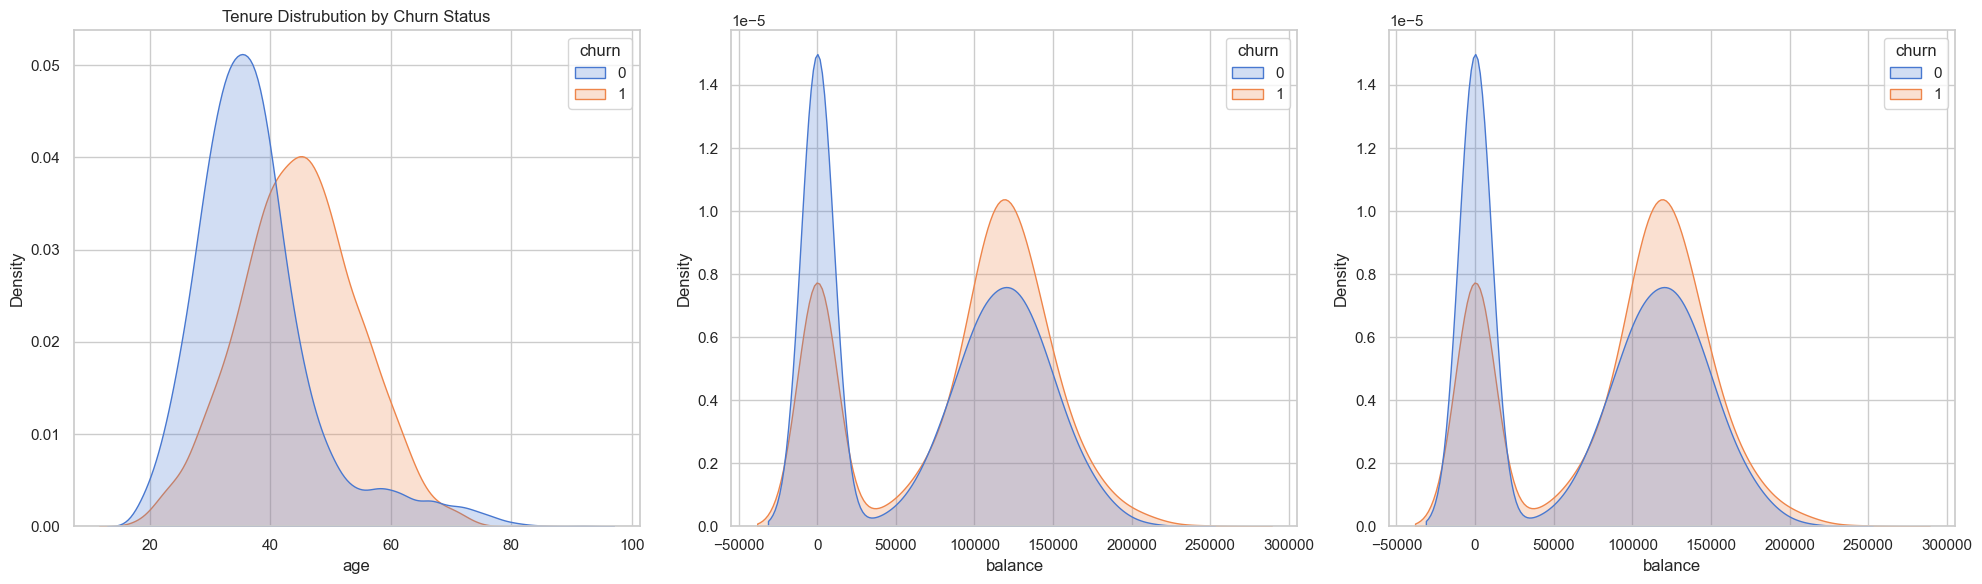

In [ ]:
# Distribution graph
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

sns.kdeplot(data=df, x='age', hue='churn', fill=True, common_norm=False, palette='muted', ax=axes[0])
axes[0].set_title('Age Distrubution by Churn Status')

sns.kdeplot(data=df, x='balance', hue='churn', fill=True, common_norm=False, palette='muted', ax=axes[1])
axes[0].set_title('Balance Distrubution by Churn Status')

sns.kdeplot(data=df, x='balance', hue='churn', fill=True, common_norm=False, palette='muted', ax=axes[2])
axes[0].set_title('Tenure Distrubution by Churn Status')

plt.tight_layout()
plt.show()


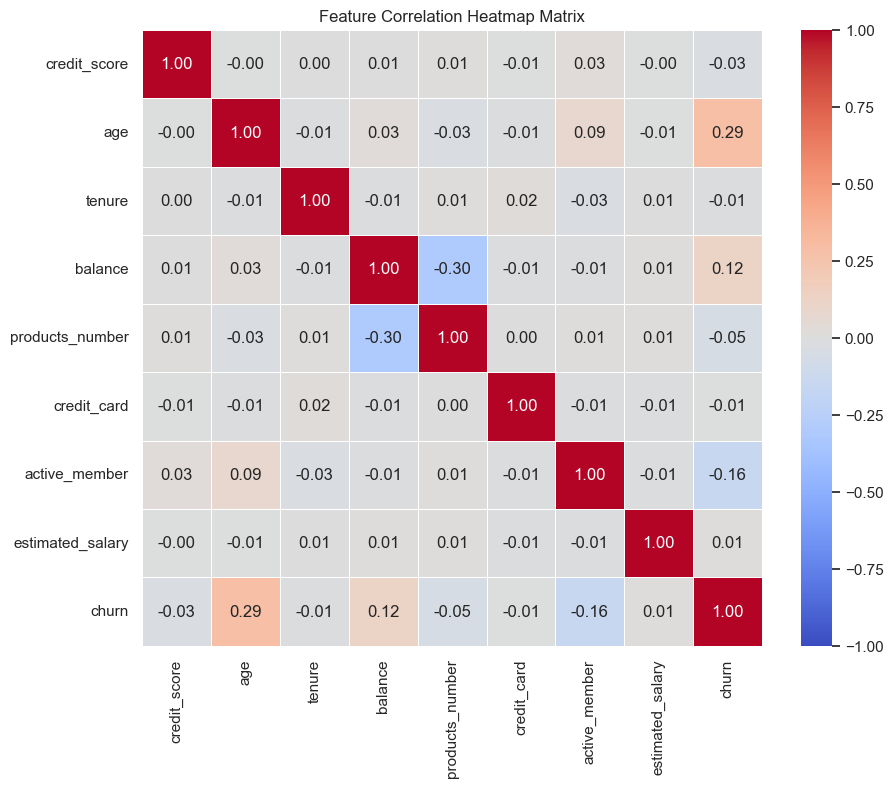

In [15]:
# Heatmap
numeric_df = df.select_dtypes(include=np.number).drop(columns=['customer_id'], errors='ignore')

corr_matrix = numeric_df.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidth=0.5, vmin=-1, vmax=1)
plt.title("Feature Correlation Heatmap Matrix")
plt.show()

/var/folders/sv/vlmp_y0x7674xh0d1j95w4zr0000gn/T/ipykernel_6536/690153535.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(['Retained (0)', 'Churned (1)'])
/var/folders/sv/vlmp_y0x7674xh0d1j95w4zr0000gn/T/ipykernel_6536/690153535.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(['Retained (0)', 'Churned (1)'])
/var/folders/sv/vlmp_y0x7674xh0d1j95w4zr0000gn/T/ipykernel_6536/690153535.py:16: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[2].set_xticklabels(['Retained (0)', 'Churned (1)'])


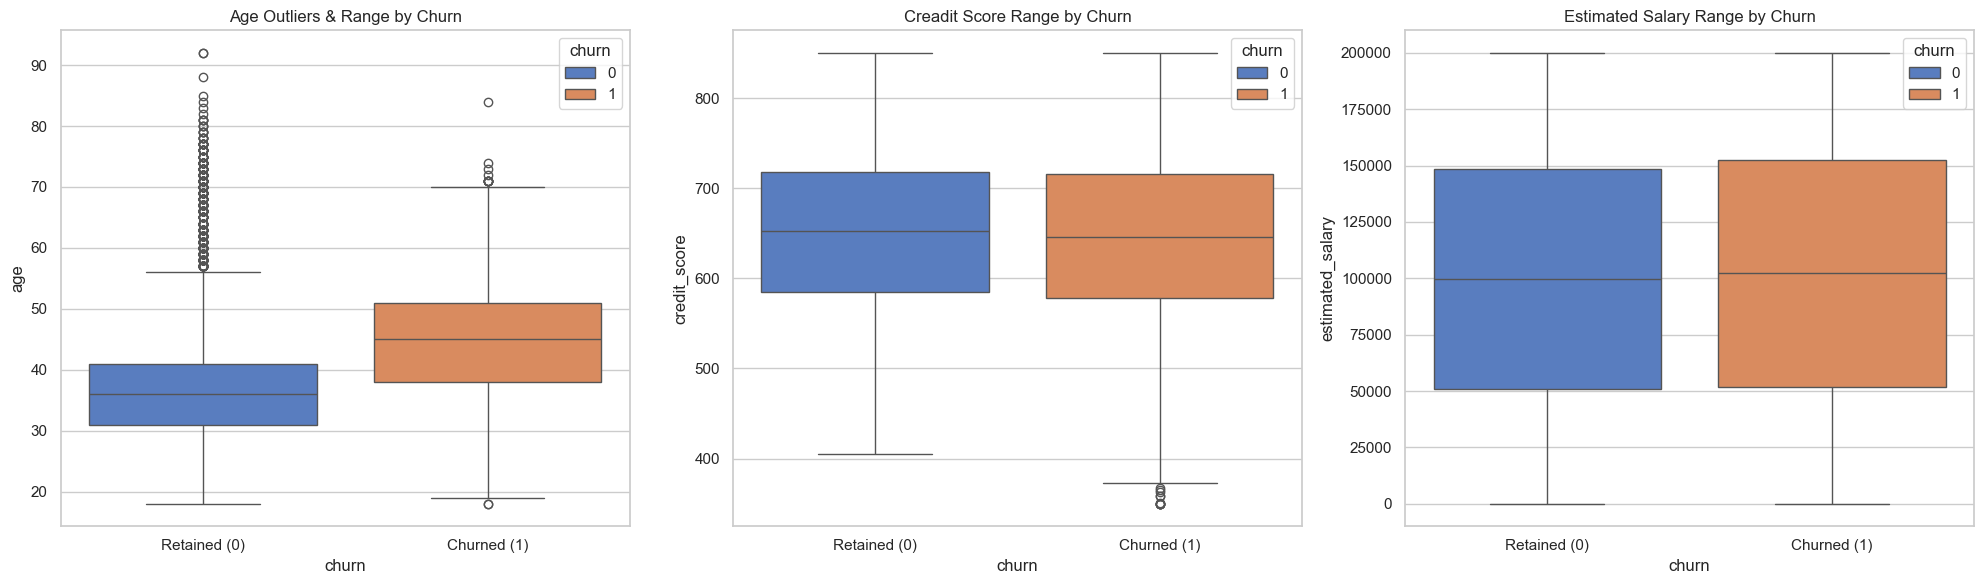

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Age 
sns.boxplot(data=df, x='churn', y='age', hue='churn', palette='muted', ax=axes[0])
axes[0].set_title("Age Outliers & Range by Churn")
axes[0].set_xticklabels(['Retained (0)', 'Churned (1)'])

# Creadit Score
sns.boxplot(data=df, x='churn', y='credit_score', hue='churn', palette='muted', ax=axes[1])
axes[1].set_title("Creadit Score Range by Churn")
axes[1].set_xticklabels(['Retained (0)', 'Churned (1)'])

# Estimated Salary
sns.boxplot(data=df, x='churn', y='estimated_salary', hue='churn', palette='muted', ax=axes[2])
axes[2].set_title("Estimated Salary Range by Churn")
axes[2].set_xticklabels(['Retained (0)', 'Churned (1)'])

plt.tight_layout()
plt.show()